# Cat Health Agentic RAG with LangChain and LangGraph

In Session 1, retrieval happened before every answer:

```text
question -> retrieve -> generate
```

In this notebook, retrieval becomes a **tool**. The agent can call that tool when it decides the user's question needs cat health guideline context.

That is the core idea of agentic RAG for this session:

```text
question -> agent decides whether to retrieve -> optional retrieval tool call -> answer
```

We will show that loop two ways:

1. **High-level LangChain path**: use `create_agent` with middleware.
2. **Explicit LangGraph path**: build the same loop with `StateGraph`, `ToolNode`, and `tools_condition`.

Both versions use the same retriever tool. The point is to see that agentic RAG is about giving the agent retrieval as an action, not forcing retrieval as a pre-step.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how agentic RAG differs from a fixed two-step RAG pipeline.
- Build and inspect a retrieval tool over a Qdrant vector store.
- Use LangChain middleware to observe and constrain an agent loop.
- Compare the convenience of `create_agent` with the control of an explicit LangGraph graph.
- Design focused routing and middleware experiments for an agentic RAG system.

## Table of Contents

- **Breakout Room #1: High-Level Agentic RAG with LangChain**
  - Task 1: Environment Setup
  - Task 2: Load and Index the Cat Health Corpus
  - Task 3: Create a Retriever Tool
  - Task 4: Build an Agent with `create_agent` and Middleware
  - Task 5: Visualize and Stream the `create_agent` Agent
  - 🏗️ Activity #1: Add a Retriever Tool-Call Budget
- **Breakout Room #2: Explicit Agent Loop with LangGraph**
  - Task 6: Build the Same Agent Loop with LangGraph
  - 🏗️ Activity #2: Add Deterministic Scope Routing
  - 🚧 Advanced Build: Add Explicit Retrieval Quality Control

---
# Breakout Room #1
## High-Level Agentic RAG with LangChain

In this breakout room, you will build the shared retrieval tool, give it to `create_agent`, and use middleware and streaming to inspect and constrain the agent loop.

## Task 1: Environment Setup

From the `02_Agentic_RAG_LangGraph_LangChain` folder, install dependencies with uv:

```bash
uv sync
```

Then open this notebook in Cursor or VS Code and select the Python/Jupyter environment created by uv.

### Imports

LangChain gives us document loading, splitting, embeddings, Qdrant integration, tools, models, and the high-level agent loop.

In [5]:
from pathlib import Path
from getpass import getpass
import os

from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware, before_model
from langchain.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_core.messages import SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

### API Keys and Models

The chat model and embedding model both use OpenAI. If `OPENAI_API_KEY` is not already set in your environment, this cell will ask for it securely.

LangSmith tracing is optional. If you set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`, LangChain/LangGraph calls will be traced automatically.

In [6]:
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

os.environ.setdefault("LANGSMITH_PROJECT", "aim-session-3-agentic-rag")

chat_model_name = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
embedding_model_name = os.environ.get("AIM_EMBEDDING_MODEL", "text-embedding-3-small")

llm = ChatOpenAI(model=chat_model_name)
embeddings = OpenAIEmbeddings(model=embedding_model_name)

print(f"Chat model: {chat_model_name}")
print(f"Embedding model: {embedding_model_name}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")

Chat model: gpt-5.4-mini
Embedding model: text-embedding-3-small
LangSmith tracing: true


## Task 2: Load and Index the Cat Health Corpus

We will use a small course-owned Markdown corpus instead of a PDF. This keeps the session focused on the agentic RAG pattern instead of PDF parsing.

**Further Reading:**
- [LangChain Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval)
- [Qdrant LangChain Integration](https://qdrant.tech/documentation/frameworks/langchain/)

In [7]:
corpus_path = Path("data/cat_health_guidelines.md")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the cat health corpus at: {corpus_path.resolve()}\n"
        "Run this notebook from the 02_Agentic_RAG_LangGraph_LangChain folder."
    )

loader = TextLoader(str(corpus_path), encoding="utf-8")
documents = loader.load()

for document in documents:
    document.metadata["source"] = corpus_path.name
    document.metadata["document_type"] = "cat_health_guidelines"

print(f"Loaded {len(documents)} document(s).")
print(documents[0].page_content[:800])
print("\nMetadata:", documents[0].metadata)

Loaded 1 document(s).
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term medication may need more frequent visits. A wellness visit may include a weight check, dental exam, vaccine review, parasite prevention review, and discussion of behavior, appetite, hydration, litter box habits, and activity level.

Preventive care is easier when owners track small changes over time. Useful observations include body weight, appetite, drinking, uri

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines'}


### Split the Corpus

Chunks should be large enough to keep a useful idea together, but small enough that retrieval returns focused context.

In [8]:
chunk_size = 900
chunk_overlap = 120

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    add_start_index=True,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " "],
)

splits = text_splitter.split_documents(documents)

for index, split in enumerate(splits):
    split.metadata["chunk_id"] = index

print(f"Created {len(splits)} chunks.")
print(splits[0].page_content[:800])
print("\nMetadata:", splits[0].metadata)

Created 10 chunks.
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines', 'start_index': 0, 'chunk_id': 0}


### Build the Qdrant Vector Store

For the course notebook, Qdrant runs in memory. There is no Docker service or cloud account required, and the collection disappears when the notebook kernel stops.

In [9]:
collection_name = "cat_health_agentic_rag"

vector_store = QdrantVectorStore.from_documents(
    documents=splits,
    embedding=embeddings,
    location=":memory:",
    collection_name=collection_name,
)

retrieval_k = 4
print(f"Built in-memory Qdrant collection: {collection_name}")

Built in-memory Qdrant collection: cat_health_agentic_rag


## Task 3: Create a Retriever Tool

This is the important shift from Session 1.

The retriever is no longer a required pre-step. It is now a tool the agent can call when it wants context from the cat health guideline corpus.

The tool name, docstring, inputs, and output format form a contract with the model. Clear contracts make good tool-selection and grounded-answer behavior more likely.

**Further Reading:**
- [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629)

In [10]:
def _format_retrieved_docs(scored_docs: list[tuple]) -> str:
    formatted_chunks = []
    for index, (doc, score) in enumerate(scored_docs, start=1):
        source = doc.metadata.get("source", "unknown")
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        start_index = doc.metadata.get("start_index", "unknown")
        score_text = f"{score:.3f}" if isinstance(score, (float, int)) else str(score)
        formatted_chunks.append(
            f"[Source {index}: {source}, chunk_id={chunk_id}, start_index={start_index}, score={score_text}]\n"
            f"{doc.page_content.strip()}"
        )
    return "\n\n".join(formatted_chunks)


@tool
def retrieve_cat_health_guidelines(query: str) -> str:
    """Search the cat health guideline corpus for relevant context about cat preventive care, nutrition, hydration, vaccines, parasites, dental health, urinary warning signs, emergencies, senior cats, stress, behavior, and safe home monitoring."""
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "No relevant cat health guideline context found."
    return _format_retrieved_docs(results)


retriever_tool = retrieve_cat_health_guidelines

Try the tool directly once. This is just to understand what the agent will see when it calls the tool.

In [11]:
print(
    retriever_tool.invoke(
        {"query": "What urinary signs suggest a cat needs urgent veterinary care?"}
    )[:2500]
)

[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.673]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased urination, new hiding, aggression, overgrooming, hair loss, bad breath, drooling, limping, coughing, sneezing that does not improve, or behavior that is unusual for the cat.

[Source 2: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.667]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention

#### ❓ Question #1

What changes when retrieval becomes a tool instead of a mandatory first step?

##### Answer:

We can modularize the retrival and make it optional to save unnecessary processing. LLM or us can decide whether we want to perform the retrieval based on what's the user asked.

## Task 4: Way 1 - Build an Agent with `create_agent` and Middleware

`create_agent` builds the agent loop for us:

1. The model reads the user question and available tools.
2. The model either answers directly or asks to call a tool.
3. If it asks for a tool, LangChain executes the tool.
4. The tool result is added back to the message history.
5. The model continues until it produces a final answer.

This is the fastest way to build agentic RAG: give the agent a retriever tool and let the agent decide when to call it.

Middleware hooks into the loop without requiring us to rebuild the graph. Below, custom `before_model` middleware logs each model step, while built-in middleware limits the number of model calls in one run.

**Further Reading:**
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)

In [53]:
AGENT_SYSTEM_PROMPT = """You are a cat health guideline assistant in an agentic RAG lesson.

You have one retrieval tool: retrieve_cat_health_guidelines.

Use the retrieval tool when the user asks about cat health, cat symptoms, preventive care, nutrition, vaccines, parasites, dental health, urinary signs, senior cats, stress, behavior, or home monitoring.

When you use retrieved context:
- Answer only from that retrieved context.
- Include a short Sources line using the source labels returned by the tool.
- Remind the user to contact a veterinarian for medical decisions, urgent symptoms, or worsening symptoms.

If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus.
If the retrieved context does not contain enough information, say you do not have enough information in the cat health guidelines to answer.
"""


@before_model
def log_before_model(state, runtime):
    """Log a compact view of each model step in the agent loop."""
    print(f"[middleware] Calling the model with {len(state['messages'])} message(s).")


agent_middleware = [
    log_before_model,
    ModelCallLimitMiddleware(run_limit=4, exit_behavior="end"),
]


agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware,
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


#### ❓ Question #2

What does middleware let us change or observe without rebuilding the agent loop? Why is a model-call limit useful?

##### Answer:

Middleware is a built-in way provided for us to add some hooks before & after the model calls and hooks run inside the compiled LangGraph that create_agent returns, which doesn't require additional runtime so we don't need to keep rebuilding the agent loop. There are so many actions we can do there and in the example we have above, ModelCallLimitMiddleware is a prebuilt one for us to limit how many times we can call the models and log_before_model is a customized one for us to print information we needed before calling the models. 

It helps with preventing infinite model call loops and saving cost within our budget.

## Task 5: Visualize and Stream the `create_agent` Agent

`create_agent` returns a compiled LangGraph graph. We can visualize that graph and stream updates to inspect when the retriever tool was called.

The exact generated graph includes middleware nodes, but its core loop is:

```text
START -> before-model middleware -> model -> after-model middleware -> END
                                                |
                                                | tool call
                                                v
                                              tools
                                                |
                                                +----> loop back to before-model middleware
```

**Further Reading:**
- [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Visualize the `create_agent` Graph

Run the next cell to render the exact compiled graph, including middleware nodes. If Mermaid PNG rendering is unavailable in your environment, the fallback prints the Mermaid source.

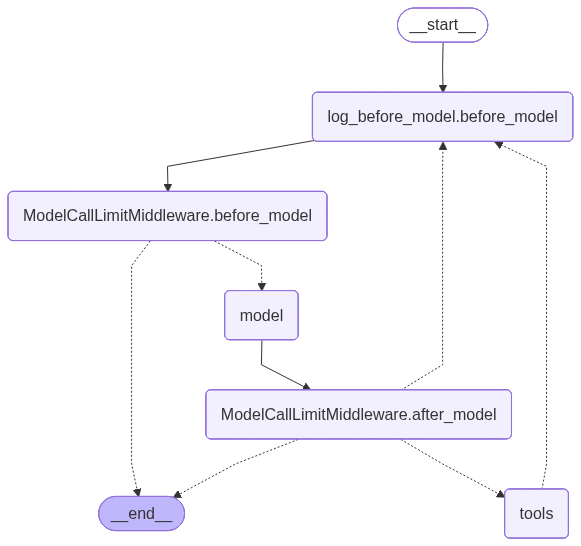

In [13]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream Agent Runs

Streaming updates lets us inspect the path the agent took. Look for tool messages to see when retrieval happened.

In [26]:
def print_agent_stream(question: str, agent):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Example 1: Cat Health Question

This should call the retrieval tool before answering.

In [15]:
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_wwUHta7kifFDI8UH15lJZTfN)
 Call ID: call_wwUHta7kifFDI8UH15lJZTfN
  Args:
    query: urinary signs in cats that require urgent veterinary care warning signs emergency difficulty urinating blood in urine frequent trips litter box straining blocked urethra pain

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.754]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain

### Example 2: Another Cat Health Question

This should also retrieve, but with a different search query.

In [16]:
print_agent_stream("What preventive care should an adult cat get each year?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_uHWmzwaySUYLzqmI41XdMat9)
 Call ID: call_uHWmzwaySUYLzqmI41XdMat9
  Args:
    query: preventive care for adult cat each year annual wellness exam vaccines parasite prevention dental care home monitoring hydration nutrition

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=1, start_index=268, score=0.787]
## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic di

### Example 3: Unrelated Question

This should not call the retrieval tool.

In [17]:
print_agent_stream("Who won the 2022 FIFA World Cup?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that question here.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}


#### ❓ Question #3

For each example, did the agent call the retrieval tool? Why or why not?

##### Answer:

Example 1: Yes, because urinary signs was mentioned in the user query and we specified in the system prompt that tool retriveval should be invoked in this case.

Example 2: Yes, same as example 1, preventive care is another topic that we want the model to listen to when deciding tool calls.

Example 3: No, because user asked something unrelated to cat health at all.

## 🏗️ Activity #1: Add a Retriever Tool-Call Budget

Middleware can enforce an operational rule without changing the retriever tool or rebuilding the agent graph. Create a second agent that allows at most **one** call to `retrieve_cat_health_guidelines` per run.

### Requirements

1. Create a `ToolCallLimitMiddleware` instance scoped to `retriever_tool.name` with `run_limit=1` and `exit_behavior="continue"`.
2. Create `budgeted_agent` with the same model, tool, prompt, and existing middleware plus the new retrieval budget.
3. Ask the agent to use separate searches for urinary emergency signs and annual preventive care before summarizing both.
4. Inspect the stream and explain what the middleware allowed or blocked.

**Further Reading:**
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)

Compiled graph nodes:
['__start__', 'model', 'tools', 'log_before_model.before_model', 'ModelCallLimitMiddleware.before_model', 'ModelCallLimitMiddleware.after_model', 'ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model', '__end__']


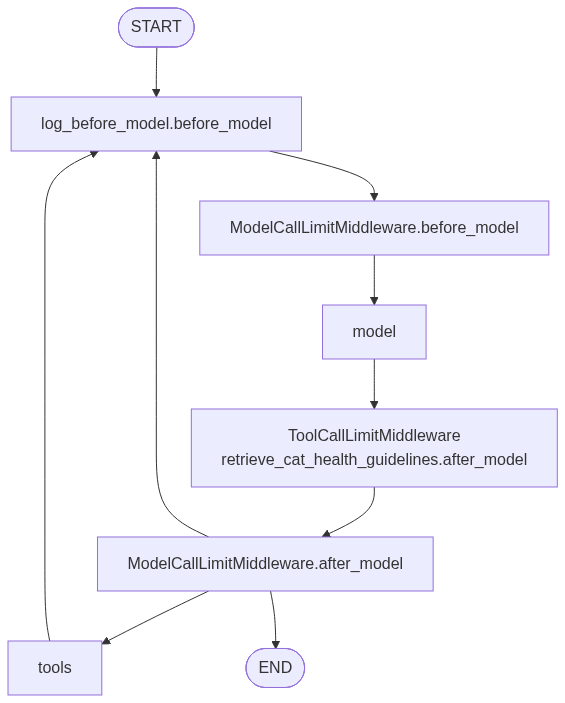

In [ ]:
# Activity #1 workspace
retrieval_budget = ToolCallLimitMiddleware(
    tool_name="retrieve_cat_health_guidelines",
    run_limit=1,
    exit_behavior="continue"
)

def visualize_budgeted_agent_graph(agent):
    """Render a Mermaid-safe PNG for budgeted_agent.

    LangChain's auto-generated Mermaid uses [tool_name] in labels, which breaks
    many Mermaid parsers. This simplified diagram matches the compiled graph.
    """
    from langchain_core.runnables.graph_mermaid import draw_mermaid_png

    nodes = list(agent.get_graph().nodes.keys())
    print("Compiled graph nodes:")
    print(nodes)

    has_tool_limit = any("ToolCallLimitMiddleware" in node for node in nodes)
    mermaid_lines = [
        "graph TD",
        "    start([START]) --> log[log_before_model.before_model]",
        "    log --> mcl_before[ModelCallLimitMiddleware.before_model]",
        "    mcl_before --> model[model]",
    ]
    if has_tool_limit:
        mermaid_lines += [
            "    model --> tcl_after[\"ToolCallLimitMiddleware<br/>retrieve_cat_health_guidelines.after_model\"]",
            "    tcl_after --> mcl_after[ModelCallLimitMiddleware.after_model]",
        ]
    else:
        mermaid_lines.append("    model --> mcl_after[ModelCallLimitMiddleware.after_model]")
    mermaid_lines += [
        "    mcl_after --> tools[tools]",
        "    mcl_after --> end_node([END])",
        "    mcl_after --> log",
        "    tools --> log",
    ]
    mermaid = "\n".join(mermaid_lines)

    try:
        png = draw_mermaid_png(mermaid_syntax=mermaid, max_retries=3, retry_delay=2.0)
        display(Image(png))
    except Exception as exc:
        print("Could not render simplified Mermaid PNG.")
        print(mermaid)
        print(f"\nRender error: {exc}")


budgeted_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware + [retrieval_budget],
)

visualize_budgeted_agent_graph(budgeted_agent)

# print_agent_stream("Can you perfrom seperate searches urinary signs & preventive care for cat health and give me a summary?", budgeted_agent)

### 📝 Activity #1 Notes

- Which retrieval calls did the agent attempt?
- Which call did the middleware allow or block?
- What quality or safety trade-off does this budget introduce?

##### Answer:
The agent was trying to attempt 2 tool retrieval calls:
```text
Tool Calls:
  retrieve_cat_health_guidelines (call_itSVAIhdsCzo7T2GROI9sOEm)
 Call ID: call_itSVAIhdsCzo7T2GROI9sOEm
  Args:
    query: urinary signs in cats warning signs prevention when to contact veterinarian
  retrieve_cat_health_guidelines (call_waaTT9DuqxzGuaLmfajmzwpq)
 Call ID: call_waaTT9DuqxzGuaLmfajmzwpq
  Args:
    query: cat preventive care vaccines parasites dental health nutrition hydration home monitoring
```

The first tool call was going thru but the second one is blocked:
```text
--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.
```
with returning the output from the first one to model:
```text
--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.695]
...

[Source 2: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.610]
...
```

This budget only allows 1 tool calls and set the exit behavior to be "continue" which allows the current run to continue naturally even if the limit has technically been reached instead of stop immediately. As for quality: The pros is that user can still get some useful result from that 1 tool call other than something like "run limit exceeded" which prevents user from seeing anything but the cons is user will get incompelete result if the model didn't communicate the limitation explicitly. As for safety: It can be used to prevent infinite tool calls from model. But the cons is model will make potentially harmful decisions from the incomplete information, which is extremeful dangerous in this case as we're asking information for cat health.


## Breakout Room #1 Summary

In BOR1, you:

- Turned retrieval into a source-labeled tool the model can choose to call.
- Built a high-level agent loop with `create_agent`.
- Used middleware to observe the loop and constrain model or tool calls.
- Used streaming to inspect retrieval decisions instead of judging only the final answer.

---
# Breakout Room #2
## Explicit Agent Loop with LangGraph

In this breakout room, you will rebuild the same model-tools loop explicitly, then add routing behavior that would require graph-level control.

## Task 6: Way 2 - Build the Same Agent Loop with LangGraph

Now we will build the minimal agent loop ourselves.

This is the same idea as `create_agent`, but expressed directly as a graph:

```text
START -> agent model -------------------------------> END
              |
              | tool call
              v
            tools
              |
              +---------------------> agent model
```

There is still no mandatory pre-retrieval step. Retrieval only happens if the model emits a tool call. Unlike middleware, graph nodes and conditional edges let us change the control flow itself.

**Further Reading:**
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

In [71]:
llm_with_tools = llm.bind_tools([retriever_tool])


def call_model(state: MessagesState):
    """Call the model with tools bound so it can choose whether to retrieve."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}

tool_node = ToolNode([retriever_tool], handle_tool_errors=True)


langgraph_builder = StateGraph(MessagesState)
langgraph_builder.add_node("agent", call_model)
langgraph_builder.add_node("tools", tool_node)

langgraph_builder.add_edge(START, "agent")
langgraph_builder.add_conditional_edges("agent", tools_condition)
langgraph_builder.add_edge("tools", "agent")

langgraph_agent = langgraph_builder.compile()
print("Compiled the explicit LangGraph agent loop.")

Compiled the explicit LangGraph agent loop.


### Visualize the Explicit LangGraph Agent

This graph should look like the core agent loop: model node, tools node, and a conditional route between them.

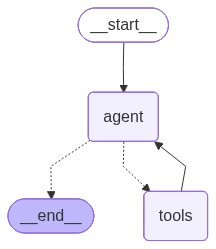

In [ ]:
try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream the Explicit LangGraph Agent

This helper is intentionally similar to `print_agent_stream`. The difference is that we are streaming from the graph we built ourselves.

In [80]:
def print_langgraph_stream(question: str, agent):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Compare the Same Questions

Run the same style of questions through the explicit LangGraph agent. The exact wording may differ, but the retrieval decision should follow the same pattern.

In [ ]:
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?", langgraph_agent)


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_yIHy4oRXia7tseA4OSLt6c1D)
 Call ID: call_yIHy4oRXia7tseA4OSLt6c1D
  Args:
    query: urinary signs urgent veterinary care cat emergency signs difficulty urinating blood in urine straining urination unable to urinate

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.660]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or producing little or no urine may have a urinary emerge

In [ ]:
print_langgraph_stream("Who won the 2022 FIFA World Cup?", langgraph_agent)


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t help with that question.


#### ❓ Question #4

What parts did `create_agent` hide that the explicit LangGraph version made visible? When would you choose middleware, and when would you change the graph itself?

##### Answer:
The optional connection (dot line edge) in between model & tool. When the model decided there is no tool retrieval needed for user query, it will directly answer the question as instructed.

Middleware controls how execution is wrapped and the graph controls what the workflow is. I would use middleware for cross-cutting concerns such as logging, tracing, retries, safety guardrails, and model/tool call limits. These apply across execution without fundamentally changing the workflow. I would customize the graph when I need to change the workflow itself: multi-agent nodes, conditional routing, human-in-the-loop steps, custom state transitions, or shared state design.

## 🏗️ Activity #2: Add Deterministic Scope Routing

The base LangGraph sends every question to the model and relies on the model to reject unrelated requests. Add a small deterministic route before the agent so clearly unrelated questions can bypass the model-tools loop.

### Requirements

1. Add an `out_of_scope` node that returns a brief scope message.
2. Add a routing function that sends likely cat-health questions to `agent` and clearly unrelated questions to `out_of_scope`.
3. Build and compile a new graph with the route immediately after `START`.
4. Test at least one cat-health question, one unrelated question, and one ambiguous question.
5. Explain where the deterministic route helps and where it is brittle.

**Further Reading:**
- [LangGraph Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)

In [ ]:
from langchain_core.messages import AIMessage


def should_route(state):
    """Return True if the question is about cat health."""
    if "cat health" in state["messages"][-1].content.lower():
        return "agent"
    else:
        return "out_of_scope"

def out_of_scope(state):
    """Return a message that the question is out of scope."""
    return {"messages": [AIMessage(content="This is out of scope for this notebook.")]}


routed_builder = StateGraph(MessagesState)
routed_builder.add_node("agent", call_model)
routed_builder.add_node("tools", tool_node)
routed_builder.add_node("out_of_scope", out_of_scope)
routed_builder.add_conditional_edges(START, should_route, {"agent": "agent", "out_of_scope": "out_of_scope"})
routed_builder.add_conditional_edges("agent", tools_condition)
routed_builder.add_edge("tools", "agent")

routed_langgraph_agent = routed_builder.compile()


# # display the graph
# try:
#     display(Image(routed_langgraph_agent.get_graph().draw_mermaid_png()))
# except Exception as exc:
#     print("Could not render Mermaid PNG. Mermaid source follows:\n")
#     print(routed_builder.get_graph().draw_mermaid())
#     print(f"\nRender error: {exc}")


# # simple testing queries
# print_langgraph_stream("tell me more about cat health", routed_langgraph_agent)
# print_langgraph_stream("what's the weather in tokyo", routed_langgraph_agent)
# print_langgraph_stream("my cat is not eating, what should i do?", routed_langgraph_agent)


--- Update from node: out_of_scope ---
================================== Ai Message ==================================

This is out of scope for this notebook.


### 📝 Activity #2 Notes

- Which questions bypassed the model-tools loop?
- What happened with the ambiguous question?
- What are the cost, latency, and quality trade-offs of this route?

##### Answer:

cat-health: "tell me more about cat health"
unrelated: "what's the weather in tokyo"
ambiguous: "my cat is not eating, what should i do?"

It got result directly from the out_of_scope node instead of going to the model.

Pros on cost and latency is pretty obvious as it only calls model when user asks cat health related questions (I know the logic is too simple for now because we only check if "cat health" in the query or not) so zero cost & fast result when in this case. However, like the ambiguous question we had above which is surely a cat health related question but didn't get answered by the model because how we define the logic inside should_route method. In this case, user didn't get any useful information.

## 🚧 Advanced Build (Optional): Add Explicit Retrieval Quality Control

The base assignment shows the minimal agentic RAG loop two ways:

1. `create_agent`
2. explicit LangGraph

If you want more control, extend the explicit LangGraph version with retrieval quality control. Good advanced additions include:

- Add a document relevance grader after retrieval.
- Add a query rewrite node when retrieval is weak.
- Add a loop limit so the agent cannot keep retrying forever.
- Add a deterministic guardrail before answering.

Those are useful production patterns, but they are not required for the core idea of agentic RAG.

---
## Summary

In this session, you:

1. Built a retrieval tool over a Qdrant vector store.
2. Used `create_agent` and middleware for a high-level agentic RAG loop.
3. Streamed agent runs to inspect when retrieval happened.
4. Rebuilt the loop explicitly with LangGraph nodes and conditional edges.
5. Practiced choosing between middleware-level constraints and graph-level routing.

### Key Takeaways

- Agentic RAG makes retrieval an available action instead of a mandatory pre-step.
- Tool contracts and system prompts strongly influence retrieval decisions.
- Middleware is useful for cross-cutting behavior such as logging, limits, retries, and guardrails.
- Explicit graphs are useful when the application needs custom state or control flow.
- Inspecting intermediate events is essential because a plausible final answer can hide a poor agent path.

### Further Reading

- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangGraph Overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Notebook Output Guidance

Keep useful outputs when you submit, especially graph diagrams and representative streamed runs that support your observations. Remove secrets, failed experiments that no longer matter, and excessively noisy output.